In [6]:
import json
import matplotlib.pyplot as plt
import numpy as np

WORKLOAD_GRANULARITY = 10

In [7]:
def extract_scenario_data(name):
    with open(name) as f:
        scenario = json.load(f)

    faults = {}
    transactions = []
    network = {}
    nodes = scenario["set_up"]["num_nodes"]

    for interval in scenario["intervals"].values():
        for key, value in interval.items():
            if key == "faults":
                for fault in value:
                    faults[fault[0]] = faults.get(fault[0], []) + [(fault[1:])]
            if key == "transactions":
                transactions += value
            if key == "network":
                for net in value:
                    network[net[0]] = network.get(net[0], []) + [net[1]]

    intervals = np.arange(0, scenario["set_up"]["duration"], WORKLOAD_GRANULARITY)
    tps = []

    counter = 0
    for end in intervals[1:]:
        itx = 0
        while transactions[counter][2] < end:
            itx += 1
            counter += 1

        tps.append(itx / WORKLOAD_GRANULARITY)

    return nodes, scenario["set_up"]["duration"], tps, network, faults

In [8]:
def plot_scenario(nodes, duration, tps, network, faults, name):
    plt.figure(figsize=(10, 3), dpi=500)

    labelsize = 7
    fontsize = 10

    plt.subplot(1, 3, 1)
    plt.plot(tps, linewidth=1, color="black", alpha=1)

    plt.grid(True, linestyle="dashed", color="gray", linewidth=0.5, alpha=0.5)
    plt.title("Workload", fontdict={"size": fontsize})
    plt.ylabel("TPS", fontdict={"size": fontsize})
    plt.xlabel("Time (S)", fontdict={"size": fontsize})

    plt.xticks(ticks=np.linspace(0, len(tps), 5), labels=np.linspace(0, duration, 5, dtype=int))
    plt.tick_params(axis="both", which="major", labelsize=labelsize)

    plt.subplot(1, 3, 2)
    plt.title("Network", fontdict={"size": fontsize})

    nets = np.array(list(network.values()))

    x = range(0, len(nets))
    y = np.mean(nets.T, axis=0)

    plt.boxplot(nets.T, vert=True, showfliers=False, positions=x, boxprops={"zorder": 3}, showmeans=True, meanprops={"marker": "x", "markersize": 3, "markeredgecolor": "black", "alpha": 0.75})

    plt.plot(x, y, alpha=0.35, linewidth=1, c="black", label="Mean")

    plt.grid(True, linestyle="dashed", color="gray", linewidth=0.5, alpha=0.5)
    plt.ylabel("Bandwidth (MB/s)", fontdict={"size": fontsize})
    plt.xlabel("Nodes", fontdict={"size": fontsize})
    plt.tick_params(axis="both", which="major", labelsize=labelsize)

    plt.subplot(1, 3, 3)
    plt.title("Faults", fontdict={"size": fontsize})

    fault_heatmap = np.ones((nodes, duration + 1))

    for node in range(nodes):
        for start, dur in faults.get(node, []):
            ofline = (int(start), int(start + dur - 1))
            for i in range(*ofline):
                if i < duration:
                    fault_heatmap[node, i] = 0

    plt.plot([], color="black", label="Offline")

    plt.grid(True, linestyle="dashed", color="gray", linewidth=0.5, alpha=0.5)
    plt.imshow(fault_heatmap, aspect="auto", interpolation="None", cmap="gray", origin="lower")
    plt.yticks(ticks=range(0, nodes), labels=range(0, nodes))
    plt.ylabel("Nodes", fontdict={"size": fontsize})
    plt.xlabel("Time (S)", fontdict={"size": fontsize})
    plt.gca().set_rasterized(True)
    plt.tick_params(axis="both", which="major", labelsize=labelsize)
    plt.tight_layout()

In [9]:
name = "light_scenario"
nodes, duration, tps, network, faults = extract_scenario_data(f"../Resources/Scenarios/{name}.json")

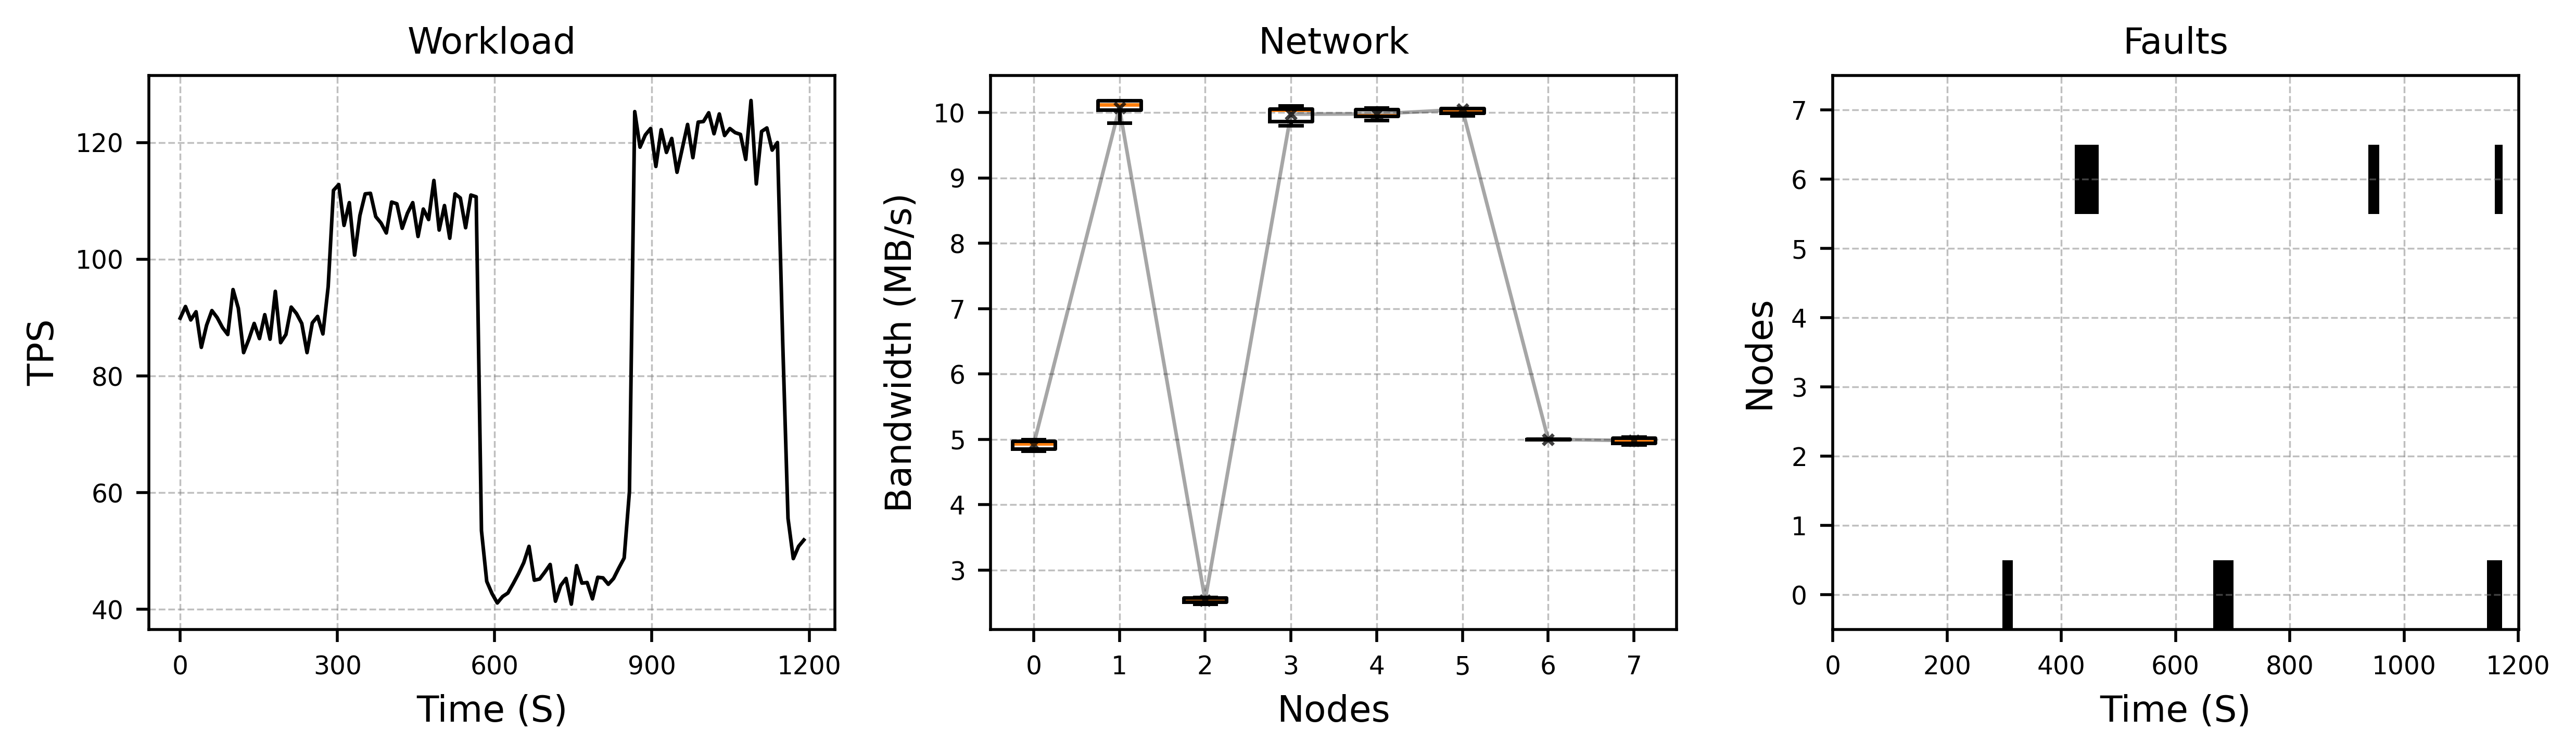

In [10]:
plot_scenario(nodes, duration, tps, network, faults, name)